In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# from OptiNet import OptiNet
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import sympy as sp
import sympy.diffgeom as dg
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import time

from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
from pathlib import Path

import random
from dataclasses import dataclass

from sympy.logic import false


In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available: {torch.cuda.is_available()}")
print(f"CUDA Version PyTorch expects: {torch.version.cuda}")
device = torch.device("cuda:0" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(device)

PyTorch version: 2.6.0+cu124
Is CUDA available: True
CUDA Version PyTorch expects: 12.4
cuda:0


In [3]:
#Import files
data_dir = Path("data")
episodes = []
for fp in sorted(data_dir.glob("data*.npz")):
    z = np.load(fp)
    episodes.append(z["data"]) 
len(episodes), episodes[1].shape

(130, (152, 13))

130
total_timestep_amount 31810


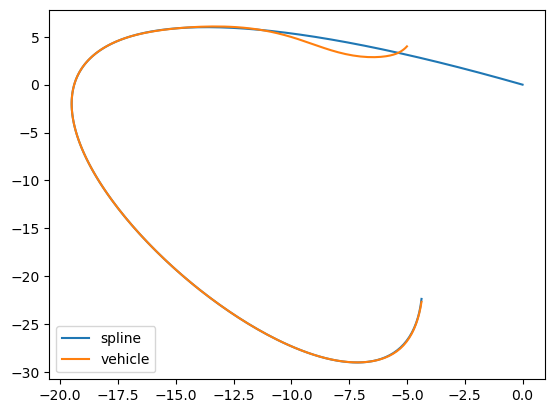

In [4]:
#Look at file data.
episode_data = episodes[45]
episode_data[100:150, :14]
total_timestep_amount = 0  #number should match X.shape[0] and Y.shape[0]

for i in range(len(episodes)):
    # print(episodes[i].shape)
    total_timestep_amount += episodes[i].shape[0]
print(len(episodes))
print("total_timestep_amount", total_timestep_amount)
plt.plot(episode_data[:, 0], episode_data[:, 1], label='spline')
plt.plot(episode_data[:, 6], episode_data[:, 7], label = 'vehicle')
plt.legend()
plt.show()

In [5]:
#Structure input files for LSTM
from copy import deepcopy
lookback = 5

def calculate_barrier_function(state, ko_data):
    #hx is CBF
    x = state[0]
    y = state[1]
    x_ko = ko_data[0]
    y_ko = ko_data[1]
    radius_ko = ko_data[2]

    hx = np.sqrt((x-x_ko)**2 + (y-y_ko)**2)-radius_ko
    return hx
     
def parse_data(data, lookback, ko_data): #TODO: Add padding so that first few values can be added to train
    data = deepcopy(data)
    X= []
    Y = []    #NN outputs force and torque, each Y_i should be accompanied with states from X_i-5 to X_i
    # print (data[1].shape)
    print("data length:", len(data))
    for episode_data in data: #go across all episodes  

        # print("episode_data",episode_data.shape)
        Y_new = episode_data[lookback:, 11:13] #Get all force and torque vectors from 1 episode. Ignore first lookback elements since no history
        # print("Y_new Shape", Y_new.shape)
        Y.append(Y_new)

        episode_length = episode_data.shape[0]
        #Need X shape (total length, lookback, data dim)
        episode_data_x = episode_data[:, 0:11] #shape 2000, 11
        
        h_values = np.array([calculate_barrier_function(row, ko_data) for row in episode_data_x])
        episode_data_x_with_h = np.column_stack((episode_data_x, h_values))
        # print("episode_data_x_with_h shape:", episode_data_x_with_h.shape)
        x_sliding_window = []

        for j in range(episode_length - lookback):
            # Grab a slice of 'lookback' length: from j to j+lookback
            window = episode_data_x_with_h[j : j + lookback]
            x_sliding_window.append(window)
            
        X.append(np.array(x_sliding_window))

    #Combine data cross all episodes into one
    print(Y[0].shape)
    print(X[0].shape)
    X = np.concatenate(X, axis=0)
    Y = np.concatenate(Y, axis=0)
    return X, Y


#insert keep out region into training data set to calculate hf
KO_DATA = [100, 100, 0.001]    #x, y, radius

X, Y = parse_data(episodes, lookback, KO_DATA)
print("X Shape",X.shape)
print("Y Shape", Y.shape)
# Y[1000:1100, :]


data length: 130
(147, 2)
(147, 5, 12)
X Shape (31160, 5, 12)
Y Shape (31160, 2)


In [6]:
# #Validate Data

# #make plot of x, y, 
# present_values = X[0:100, -1, :]
# present_values.shape

# h_x = present_values[:, -1]
# x_spline = present_values[:, 0]
# y_spline = present_values[:, 1]
# x_cur = present_values[:, 6]
# y_cur = present_values[:, 7]

# plt.plot(h_x)
# plt.title("H(x) values")
# # plt.ylim(-10, 50)
# plt.show()

# fig, ax = plt.subplots()
# ax.plot(x_cur, y_cur, label='Current Path')
# ax.plot(x_spline, y_spline, label='Spline')
# circle_x, circle_y, radius = KO_DATA[0], KO_DATA[1], KO_DATA[2] # Replace with your actual values
# circle = plt.Circle((circle_x, circle_y), radius, color='r', fill=False, label='Boundary')
# ax.add_patch(circle)
# ax.set_aspect('equal', adjustable='datalim')

# plt.legend
# plt.show()


In [7]:

split_index = int(len(X) * 0.8)
X_train = X[:split_index]
X_test = X[split_index:]

Y_train = Y[:split_index]
Y_test = Y[split_index:]

X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()


X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


(torch.Size([24928, 5, 12]),
 torch.Size([6232, 5, 12]),
 torch.Size([24928, 2]),
 torch.Size([6232, 2]))

In [8]:
class TrajectoryDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]

train_dataset = TrajectoryDataset(X_train, Y_train)
test_dataset = TrajectoryDataset(X_test, Y_test)

from torch.utils.data import DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [9]:
for _, batch in enumerate(train_loader):
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    break



torch.Size([16, 5, 12]) torch.Size([16, 2])


In [46]:
class LSTM(nn.Module):

    # input size = number features = 12
    #hidden size can be anything, use 20 for now
    #num_stacked_layers, idk what it does
    def __init__(self, input_size, hidden_1_size, hidden_2_size, num_stacked_layers):
        super().__init__()
        self.hidden_1_size = hidden_1_size
        self.num_stacked_layers = num_stacked_layers
        self.lstm = nn.LSTM(input_size, hidden_1_size, num_stacked_layers,
                            batch_first=True)
        self.fc1 = nn.Linear(hidden_1_size, hidden_2_size)
        self.fc2 = nn.Linear(hidden_2_size, 2)
        u_f = cp.Variable(1)   
        A = cp.Parameter(1)
        b = cp.Parameter(1)
        u_f_nom_param = cp.Parameter(1)
        constraints = [A @ u_f + b >= 0]

        objective = cp.Minimize(0.5 * cp.pnorm(u_f-u_f_nom_param, p=2)**2)
        problem = cp.Problem(objective, constraints)
        assert problem.is_dpp()

        self.layer = CvxpyLayer(problem, parameters=[A, b, u_f_nom_param], variables=[u_f]).to(device)

 


    def get_cbf_coeff(self, state, ko_data, k1, k2): 
        
        #x shape torch.Size([16, 5, 12])
        current_state = state[:, -1, :]  #only want last time of LSTM

        x = current_state[:,0]
        y = current_state[:,1]
        theta = current_state[:,2]
        v = current_state[:,3]
        omega = current_state[:,4]
        x_ko = ko_data[0]
        y_ko = ko_data[1]
        r_ko = ko_data[2]

        # print(f"State device: {state.device}")
        # print(f"KO data device: {ko_data.device}")

        #helper variables
        x_err = x_ko - x
        y_err = y_ko - y
        v_err = x_err**2 + y_err**2

        r1 = (v_err**(7/2)) * x_err
        r2 = (v_err**(7/2)) * y_err
        r3 = (v_err**(5/2)) * (x_err**2)
        r4 = (v_err**(5/2)) * (y_err**2)
        r5 = (v_err**(5/2)) * x_err * y_err

        #Coeff for input
        u_f_coeff = (2*r1*torch.cos(theta) + 2*r2*torch.sin(theta)) / (2 * v_err**4 + 1e-6)  #add small number to prevent divide by 0

        #other coeffs
        term1 = -2 * k1 * k2 * (v_err**(9/2))
        term2 = 2 * k1 * k2 * v_err**4 * r_ko
        term3 = -2 * r1 * torch.sin(theta) * v * omega
        term4 = 2 * r2 * torch.cos(theta) * v * omega
        term5 = r3 * torch.cos(2 * theta) * (v**2)
        term6 = r3 * (v**2)
        term7 = -r4 * torch.cos(2 * theta) * (v**2) 
        term8 = r4 * (v**2)
        term9 = 2 * r5 * torch.sin(2 * theta) * (v**2)
        term10 = -2 * (v_err**(7/2)) * (v**2)

        numerator = -(term1 + term2 + term3 + term4 + term5 + 
                        term6 + term7 + term8 + term9 + term10)

        denominator = 2 * v_err**4 +1e-6  #add small number to prevent divide by 0

        const_coeff = numerator / denominator

        return u_f_coeff, const_coeff



    def forward(self, x, ko_data, k1, k2):
        # print("x shape" ,x.shape)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_1_size, device = device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_1_size, device = device)

        out, _ = self.lstm(x, (h0, c0))

        out = self.fc1(out[:, -1, :]) # get only last value in LSTM output
        out = self.fc2(out)
        return out     #uncomment this line to test without CBF constraint

        u_f_nom = out[:, 0:1]  #keep 16, 1 shape since only u_f need to be inputted to cbf
        u_t_nom = out[:, 1:2]
        u_f_coeff, const_coeff = self.get_cbf_coeff(x, ko_data, k1, k2)

        A_tch = u_f_coeff.reshape(-1, 1).cpu()
        b_tch = const_coeff.reshape(-1, 1).cpu()
        u_f_nom_cpu = u_f_nom.cpu()

        # solve the problem
        try:
            (solution_cpu,) = self.layer(A_tch, b_tch, u_f_nom_cpu)

            u_f_safe = solution_cpu.to(device)            

        except Exception as e:
            # It's better to print the error 'e' to see WHY it failed
            print(f"Solver failed: {e}")
            u_f_safe = u_f_nom
        # u_diff = torch.abs(u_f_nom-u_f_safe).mean().item()
        # print(" u_diff: ", (u_diff)) 
        return torch.cat([u_f_safe, u_t_nom], dim=1).float()

model = LSTM(12, 500, 100, 1)

model.to(device)
print(device)
model


cuda:0


LSTM(
  (lstm): LSTM(12, 500, batch_first=True)
  (fc1): Linear(in_features=500, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=2, bias=True)
  (layer): CvxpyLayer()
)

In [ ]:
loss_function = nn.MSELoss()
learning_rate = 0.002
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
num_epochs = 8
k1 = torch.tensor([1], requires_grad=False)
k2 = torch.tensor([1], requires_grad=False)

def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):

        x_batch, y_batch = batch[0].to(device), batch[1].to(device) #make things on device
        ko_data_torch = torch.tensor(KO_DATA)
        ko_data_torch = ko_data_torch.to(device)
        k1_torch = k1.to(device)
        k2_torch = k2.to(device)

        output = model(x_batch, ko_data_torch, k1_torch, k2_torch)     
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 100 == 99:  # debug every 100 batches
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1, avg_loss_across_batches))

            print("-" * 30)
            print("LAYER GRADIENTS")
            print("-" * 30)
            for name, param in model.named_parameters():
                if param.grad is not None:
                    # Calculate the average magnitude of the gradient
                    avg_grad = param.grad.abs().mean().item()
                    max_grad = param.grad.abs().max().item()
                    print(f"Layer: {name:20} | Mean Grad: {avg_grad:.6e} | Max Grad: {max_grad:.6e}")
                else:
                    print(f"Layer: {name:20} | Grad: NONE (Disconnected)")
            print("-" * 30)

            running_loss = 0.0

        if batch_index > 1200:
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0

            break
    print()

In [48]:
start_time = time.time() # Start the global clock
for epoch in range(num_epochs):
    train_one_epoch()
    # validate_one_epoch()

total_duration = time.time() - start_time    
print(f"Total Training Time: {total_duration/60:.2f} minutes")

'''For soem reason solver cannot solve when KO is far away but can solve when close by??? could be because numerical solver cant handle big distances well?
'''

Epoch: 1
Batch 100, Loss: 1.936
------------------------------
LAYER GRADIENTS
------------------------------
Layer: lstm.weight_ih_l0    | Mean Grad: 6.185255e-03 | Max Grad: 6.022861e+00
Layer: lstm.weight_hh_l0    | Mean Grad: 2.189246e-05 | Max Grad: 3.250153e-02
Layer: lstm.bias_ih_l0      | Mean Grad: 2.713872e-04 | Max Grad: 4.271216e-02
Layer: lstm.bias_hh_l0      | Mean Grad: 2.713872e-04 | Max Grad: 4.271216e-02
Layer: fc1.weight           | Mean Grad: 2.240977e-03 | Max Grad: 8.556485e-02
Layer: fc1.bias             | Mean Grad: 3.260748e-02 | Max Grad: 8.585863e-02
Layer: fc2.weight           | Mean Grad: 3.779010e-02 | Max Grad: 2.149813e-01
Layer: fc2.bias             | Mean Grad: 5.620417e-01 | Max Grad: 1.041606e+00
------------------------------
Batch 200, Loss: 1.813
------------------------------
LAYER GRADIENTS
------------------------------
Layer: lstm.weight_ih_l0    | Mean Grad: 5.531247e-03 | Max Grad: 2.447957e+00
Layer: lstm.weight_hh_l0    | Mean Grad: 1.1337

'For soem reason solver cannot solve when KO is far away but can solve when close by??? could be because numerical solver cant handle big distances well?\n'

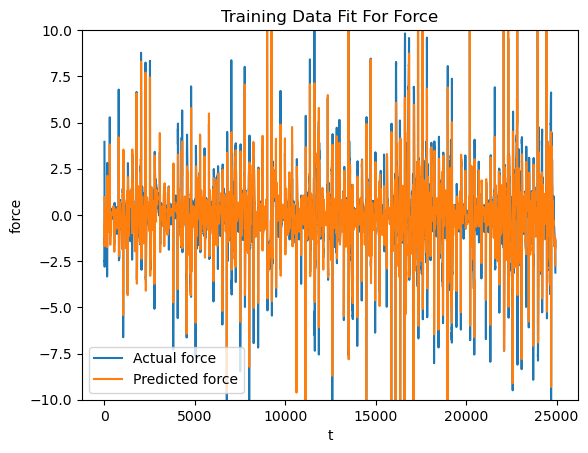

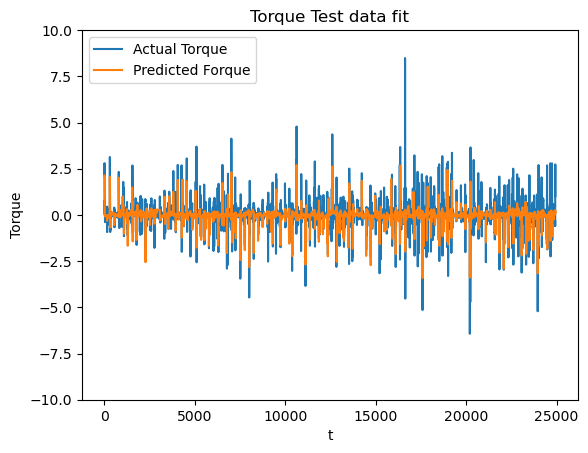

In [53]:
model.train(False)

#"Seeing how well it fits training data"

with torch.no_grad():
    ko_data_torch = torch.tensor(KO_DATA)
    ko_data_torch = ko_data_torch.to(device)
    k1_torch = k1.to(device)
    k2_torch = k2.to(device)
    predicted = model(X_train.to(device),  ko_data_torch, k1_torch, k2_torch).to('cpu').numpy()


plt.plot(Y_train[:,0], label='Actual force')
plt.plot(predicted[:,0], label='Predicted force')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('force')
plt.legend()
plt.title("Training Data Fit For Force")
plt.show()

plt.plot(Y_train[:,1], label='Actual Torque')
plt.plot(predicted[:,1], label='Predicted Forque')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('Torque')
plt.legend()
plt.title("Torque Test data fit")
plt.show()

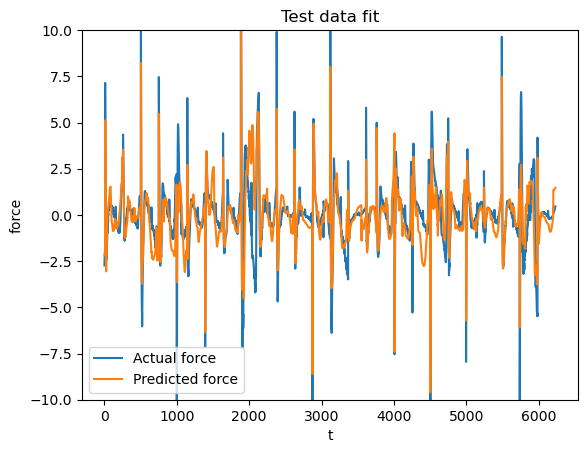

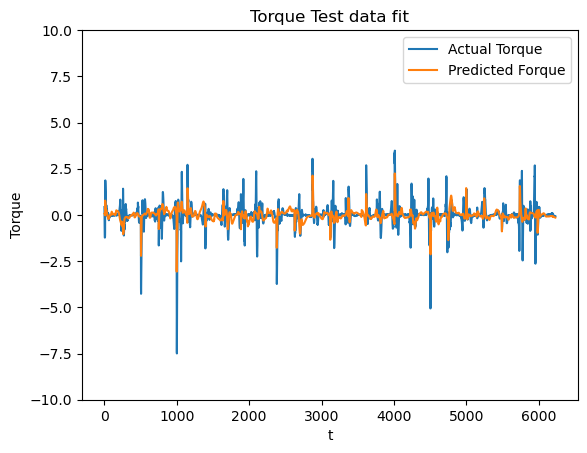

In [49]:
#Test data

with torch.no_grad():
    ko_data_torch = torch.tensor(KO_DATA)
    ko_data_torch = ko_data_torch.to(device)
    k1_torch = k1.to(device)
    k2_torch = k2.to(device)
    predicted = model(X_test.to(device), ko_data_torch, k1_torch, k2_torch).to('cpu').numpy()


plt.plot(Y_test[:,0], label='Actual force')
plt.plot(predicted[:,0], label='Predicted force')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('force')
plt.legend()
plt.title("Test data fit")
plt.show()

plt.plot(Y_test[:,1], label='Actual Torque')
plt.plot(predicted[:,1], label='Predicted Forque')
plt.xlabel('t')
plt.ylim(-10, 10)
plt.ylabel('Torque')
plt.legend()
plt.title("Torque Test data fit")
plt.show()

In [77]:
dt = 0.01
t_final = 30.0
num_samples = int(t_final / dt)
t = np.linspace(0, t_final, num_samples)

#create random points
x_initial_max = 1
y_initial_max = 1
initial_vel_variance = 2
initial_dot_theta_variance = 2
initial_force_variance = 5
initial_torque_variance = 1.5

x0 = random.randint(-x_initial_max, x_initial_max)
y0 = random.randint(-y_initial_max, y_initial_max)
theta0 = np.random.uniform(0, np.pi/2)
vel0 = np.random.uniform(-initial_vel_variance, initial_vel_variance)
dot_theta0 = np.random.uniform(-initial_torque_variance, initial_torque_variance)
force0 = np.random.uniform(-initial_dot_theta_variance, initial_dot_theta_variance)
torque0 = np.random.uniform(-initial_torque_variance, initial_torque_variance)

p0 = np.array([x0, y0, theta0, vel0, dot_theta0])  # pointing straight up
u0 = np.array([force0, torque0])
p_hist = np.array([])
u_hist = np.array([])

KO_DATA_PRED = [100, 100, 0.001]    #x, y, radius
p_hist = np.tile(p0, (lookback, 1)) 
u_hist = np.tile(u0, (lookback, 1))
p_hist.shape



(5, 5)

In [78]:
#Spline generation

def generate_spline(t_final, points = None, dt=0.01, spline_type="cubic"):
    spline_method = CubicSpline  # for convenience
    t = np.linspace(0, t_final, int(t_final / dt))
    if points is None:
        points = np.array([(0.0, 0.0, 0.0), (5.0, 5.0, t_final / 2), (10.0, 0.0, t_final)])


    (x_spline, y_spline) = (
        spline_method(points[:, 2], points[:, 0]),
        spline_method(points[:, 2], points[:, 1]),
    )
    (traj_x, traj_y, dot_traj_x, dot_traj_y) = (
        x_spline(t),
        y_spline(t),
        x_spline.derivative()(t),
        y_spline.derivative()(t),
    )

    (traj_theta, dot_traj_theta) = (
        np.atan2(traj_y, traj_x),
        np.atan2(dot_traj_y, dot_traj_x),
    )
    traj = (traj_x, traj_y, traj_theta, dot_traj_x, dot_traj_y, dot_traj_theta)
    # fig, ax = plt.subplots()
    # ax.plot(traj_x, traj_y)

    # plt.show()
    print("traj_x" ,len(traj_x))
    return traj, t

spline_method = CubicSpline
path_points = np.array([(0.0, 0.0, 0.0), (1.0, 3.0, t_final / 4), (4, 2, 2*t_final/3), (5.0, 0.0, t_final)])  #smooth test spline

# generators for the spline
x_spline, y_spline = (
    spline_method(path_points[:, 2], path_points[:, 0]),
    spline_method(path_points[:, 2], path_points[:, 1]),
)

# computes the array indices
x_traj, y_traj, x_dot_traj, y_dot_traj = (
    x_spline(t),
    y_spline(t),
    x_spline.derivative()(t),
    y_spline.derivative()(t),
)
(theta_traj, dot_theta_traj) = (
    np.atan2(x_traj, y_traj),
    np.atan2(x_dot_traj, y_dot_traj),
)

# generates a lookup handle
def traj(t):
    closest_idx = int(round(t / dt))
    return (x_traj[closest_idx], y_traj[closest_idx], theta_traj[closest_idx])
traj = np.column_stack((x_traj, y_traj, theta_traj, x_dot_traj, y_dot_traj, dot_theta_traj))
traj_padded = np.pad(traj, ((lookback-1, 0), (0, 0)), mode='edge')
# plt.plot(x_traj, y_traj)
traj_padded[0:6, :]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.55555556e-02,
        6.73333333e-01, 5.27562818e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.55555556e-02,
        6.73333333e-01, 5.27562818e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.55555556e-02,
        6.73333333e-01, 5.27562818e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.55555556e-02,
        6.73333333e-01, 5.27562818e-02],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.55555556e-02,
        6.73333333e-01, 5.27562818e-02],
       [3.57267383e-04, 6.73146530e-03, 5.30244863e-02, 3.58740646e-02,
        6.72511024e-01, 5.32929491e-02]])

In [79]:
def calculate_barrier_function(state, ko_data):
    #hx is CBF
    x = state[:, 0]
    y = state[:, 1]
    x_ko = ko_data[0]
    y_ko = ko_data[1]
    radius_ko = ko_data[2]

    hx = np.sqrt((x-x_ko)**2 + (y-y_ko)**2)-radius_ko
    return hx.reshape(-1, 1)

def dyn_ext_unicycle_model_step(t, dt, y, u, ):
    u_f, u_t = u

    def model_f(t, y):
        _, _, theta, v, omega = y
        return np.array([v * np.cos(theta), v * np.sin(theta), omega, u_f, u_t])

    result = solve_ivp(model_f, [0, dt], y)
    return result.y[:, -1]


p_curr = p0
p_curr_window = p_hist[-lookback:, :] #making sliding window for LSTM
for i in range(num_samples):
    t_curr = t[i]
    
    # generate the next control action
    ko_data_torch = torch.tensor(KO_DATA)
    ko_data_torch = ko_data_torch.to(device)
    k1_torch = k1.to(device)
    k2_torch = k2.to(device)

    hx = calculate_barrier_function(p_curr_window, KO_DATA_PRED)
    input_data = np.column_stack((traj_padded[i:i+lookback, :], p_curr_window, hx))
    input_tensor = torch.from_numpy(input_data).float().unsqueeze(0).to(device)

    with torch.no_grad():
        predicted = model(input_tensor, ko_data_torch, k1_torch, k2_torch).to('cpu').detach().numpy()
    print("predicted shape", predicted.shape)
    u_f_pred = predicted[-1, 0]  # get the last control action from the predicted sequence
    u_t_pred = predicted[-1, 1]


    # update the model with the optimal control
    p_curr = dyn_ext_unicycle_model_step(
        t_curr, dt, p_curr, predicted[-1, :], 
    )

    #update history and sliding window
    p_hist = np.vstack((p_hist, p_curr))
    u_hist = np.vstack((u_hist, predicted[-1, :]))

    p_curr_window = np.vstack((p_curr_window[1:], p_curr))
    if i > 300:
        break



predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted shape (1, 2)
predicted s

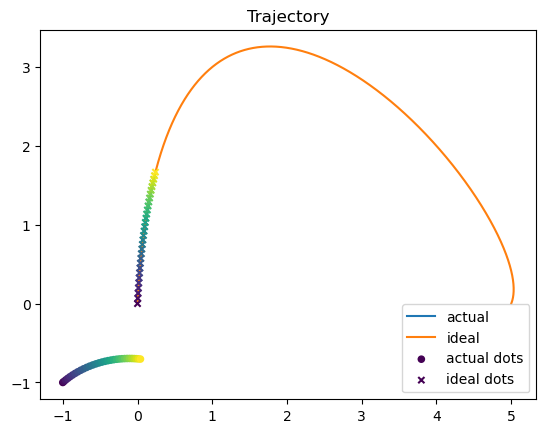

In [80]:
step = 10
indices = np.arange(0, len(p_hist), step)
plt.plot(p_hist[:, 0], p_hist[:, 1], label = "actual")
plt.plot(x_traj, y_traj, label = "ideal")

# 2. Add dots that change color over time
# 'c=indices' tells matplotlib to color based on the time step
# 'cmap' defines the color gradient (e.g., 'viridis', 'plasma', 'jet')
scatter_actual = plt.scatter(p_hist[indices, 0], p_hist[indices, 1], 
                             c=indices, cmap='viridis', s=20, label="actual dots", zorder=3)

scatter_ideal = plt.scatter(x_traj[indices], y_traj[indices], 
                            c=indices, cmap='viridis', s=20, marker='x', label="ideal dots", zorder=3)

# Optional: Add a colorbar to show time progression
# plt.colorbar(scatter_actual, label="Time Step")
plt.title("Trajectory")
plt.legend()


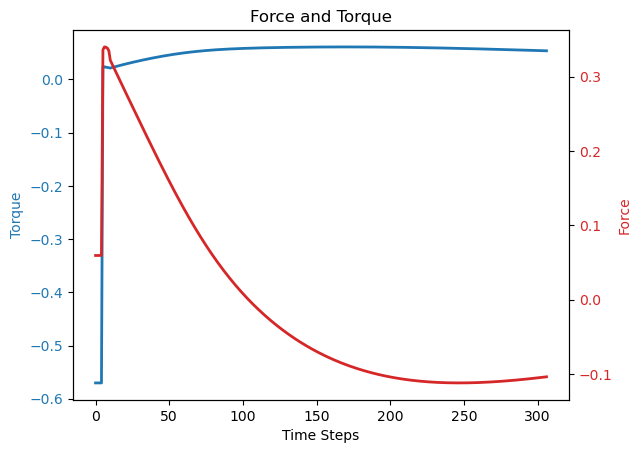

In [81]:
ax1 = plt.subplot(1, 1, 1)

# Plot Angle on the Left Y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Torque', color=color1)
ax1.plot(u_hist[:, 1], color=color1, linewidth=2) #force
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_title("Force and Torque")
ax2 = ax1.twinx() 

# Plot Velocity on the Right Y-axis
color2 = 'tab:red'
ax2.set_ylabel('Force', color=color2)
ax2.plot(u_hist[:, 0], color=color2, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color2)